<a href="https://colab.research.google.com/github/mickael044/CodeAlpha_CreditScoring/blob/main/CodeAlpha_CreditScoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CodeAlpha Internship: Credit Scoring Model

**Objective:** Predict whether a loan applicant is a good or bad credit risk based on financial and personal history, comparing Logistic Regression, Decision Tree, Random Forest, and a tuned XGBoost model.

**Dataset:** German Credit Data (UCI), 1000 samples, 20 features.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# German Credit Data (UCI) - URL-dən birbaşa yüklə
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "checking_account", "duration", "credit_history", "purpose", "credit_amount",
    "savings_account", "employment_since", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age", "other_installment_plans",
    "housing", "existing_credits", "job", "num_dependents", "telephone",
    "foreign_worker", "target"
]

df = pd.read_csv(url, sep=" ", header=None, names=columns)

print("Ölçü:", df.shape)
df.head()

Ölçü: (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [17]:
import urllib.request
raw_text = urllib.request.urlopen(url).read().decode("utf-8")
print(raw_text[:300])

A11 6 A34 A43 1169 A65 A75 4 A93 A101 4 A121 67 A143 A152 2 A173 1 A192 A201 1
A12 48 A32 A43 5951 A61 A73 2 A92 A101 2 A121 22 A143 A152 1 A173 1 A191 A201 2
A14 12 A34 A46 2096 A61 A74 2 A93 A101 3 A121 49 A143 A152 1 A172 2 A191 A201 1
A11 42 A32 A42 7882 A61 A74 2 A93 A103 4 A122 45 A143 A153 1 


In [18]:
# cheks the target
print(df["target"].value_counts())

# 1 = good credit, 2 = bad credit -> convert it for the model
# 0 = good credit (no risk), 1 =  bad credit (there is risk)
df["target"] = df["target"].map({1: 0, 2: 1})

print(df["target"].value_counts())

target
1    700
2    300
Name: count, dtype: int64
target
0    700
1    300
Name: count, dtype: int64


In [19]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categoric column:", cat_cols)
print("Sayı:", len(cat_cols))

num_cols = df.select_dtypes(exclude="object").columns.tolist()
print("Numerical Column:", num_cols)

Categoric column: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Sayı: 13
Numerical Column: ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'target']


In [20]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,0
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,1
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,0
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,0
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account         1000 non-null   int64
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   int64
 3   purpose                  1000 non-null   int64
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   int64
 6   employment_since         1000 non-null   int64
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   int64
 9   other_debtors            1000 non-null   int64
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   int64
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   int64
 14  housing                  1000 non-null   int64
 15  exist

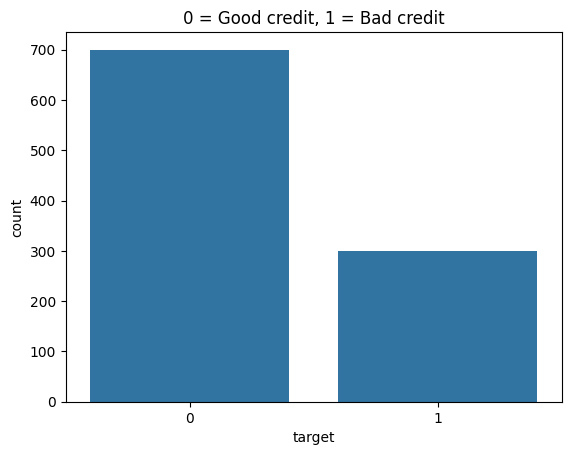

In [21]:
# 1.general information
df_encoded.info()

# 2. there is empty value?
print("Empty values:", df_encoded.isnull().sum().sum())

# 3. Target balans
print(df_encoded["target"].value_counts())
sns.countplot(x="target", data=df_encoded)
plt.title("0 = Good credit, 1 = Bad credit")
plt.show()

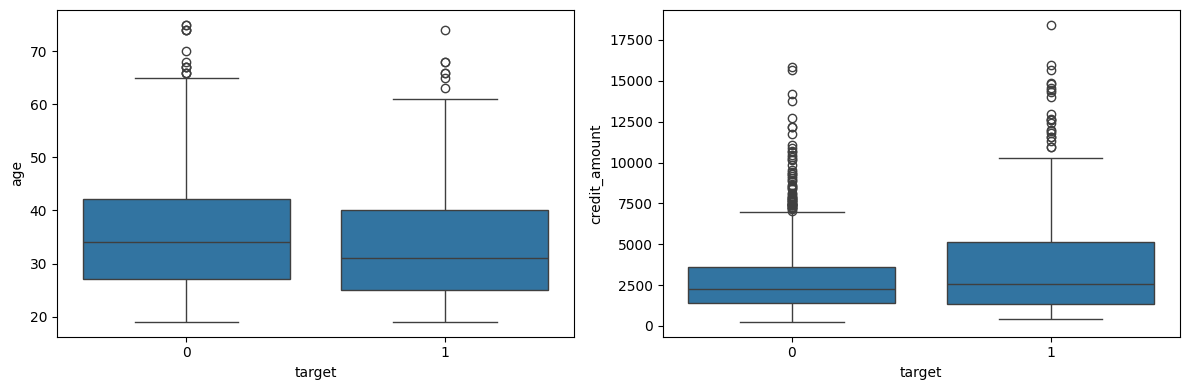

checking_account           0.350847
credit_history             0.228785
duration                   0.214927
savings_account            0.178943
credit_amount              0.154739
property                   0.142612
employment_since           0.116002
other_installment_plans    0.109844
age                        0.091127
personal_status_sex        0.088184
Name: target, dtype: float64


In [22]:
# 4. The relationship between age, credit amount, and the target variable
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x="target", y="age", data=df_encoded)
plt.subplot(1, 2, 2)
sns.boxplot(x="target", y="credit_amount", data=df_encoded)
plt.tight_layout()
plt.show()

# 5. The 10 features most strongly related to the target
corr = df_encoded.corr()["target"].abs().sort_values(ascending=False)[1:11]
print(corr)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

# 2. Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled = scaler.transform(X_test)         # transform test only

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (800, 20)
Test: (200, 20)


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Try XGBoost with scale_pos_weight to handle imbalance without hurting accuracy as much
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
}

grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.76
Precision: 0.591
Recall: 0.65
F1: 0.619
ROC-AUC: 0.8


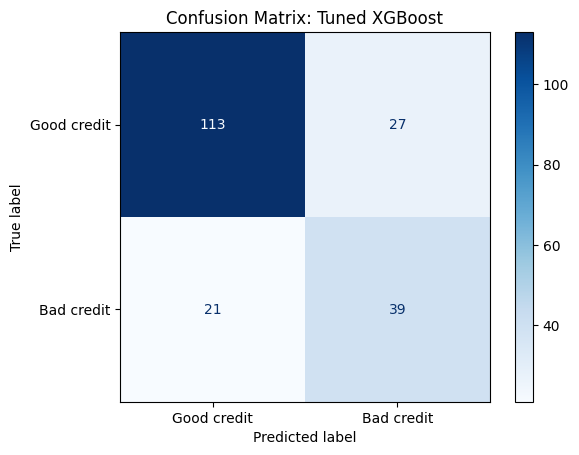

              precision    recall  f1-score   support

 Good credit       0.84      0.81      0.82       140
  Bad credit       0.59      0.65      0.62        60

    accuracy                           0.76       200
   macro avg       0.72      0.73      0.72       200
weighted avg       0.77      0.76      0.76       200



In [25]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve

# 1. Confusion matrix for the tuned XGBoost model
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Good credit", "Bad credit"],
    cmap="Blues"
)
plt.title("Confusion Matrix: Tuned XGBoost")
plt.show()

# 2. Detailed report
print(classification_report(y_test, y_pred, target_names=["Good credit", "Bad credit"]))

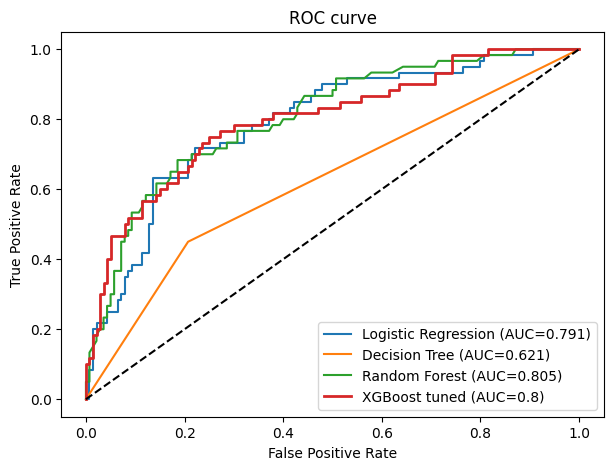

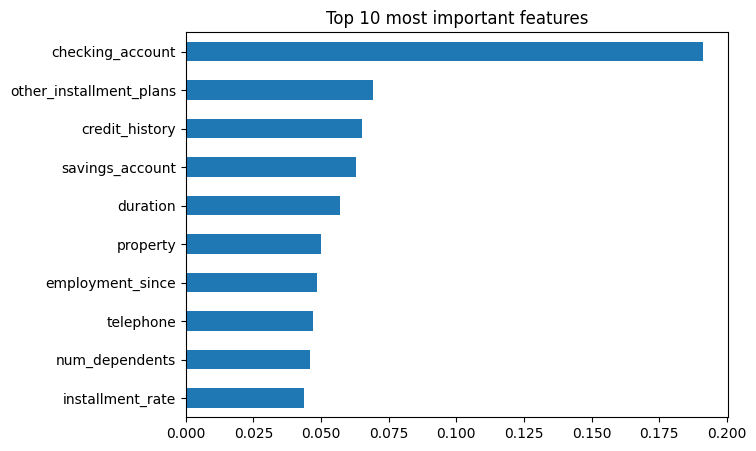

In [26]:
# 3. ROC curve: compare the tuned XGBoost against the earlier baseline models
plt.figure(figsize=(7, 5))

for name, model in trained.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = results_df.loc[name, "ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc})")

# Add the tuned XGBoost
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"XGBoost tuned (AUC={round(roc_auc_score(y_test, y_proba), 3)})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

# 4. Feature importance from the tuned XGBoost model
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
importances.sort_values().plot(kind="barh", figsize=(7, 5), title="Top 10 most important features")
plt.show()

## Conclusion

**Model iteration:** I didn't stop at the first result. I trained three baseline models first (Logistic Regression, Decision Tree, Random Forest), then improved them with `class_weight="balanced"` to handle the class imbalance, and finally tuned an XGBoost model with GridSearchCV to push performance further.

| Stage | Best model | Accuracy | F1 | Recall (bad credit) | ROC-AUC |
|---|---|---|---|---|---|
| 1. Baseline (no balancing) | Random Forest | ~0.73 | ~0.45 | ~0.35 | ~0.78 |
| 2. Balanced classes | Random Forest | 0.77 | 0.511 | 0.40 | 0.805 |
| 3. Tuned XGBoost (GridSearchCV) | XGBoost | 0.76 | **0.619** | **0.65** | 0.80 |

- **Best model:** The tuned XGBoost model offers the best overall balance. While Random Forest had a slightly higher accuracy and ROC-AUC, the tuned XGBoost catches 65% of bad credit cases (recall) compared to only 40% for Random Forest, with a meaningfully higher F1-score (0.619 vs 0.511). In credit risk, catching more bad credit cases matters more than a small accuracy gain.
- **Class imbalance:** The dataset is imbalanced (700 good credit, 300 bad credit). Addressing this with `class_weight="balanced"` and `scale_pos_weight` was the single biggest driver of improvement, nearly doubling recall on the minority class.
- **Most important features:** checking account status, other installment plans, credit history, and savings account are the strongest predictors of credit risk.
- **Business note:** In credit scoring, missing a bad credit case (false negative) is costlier than rejecting a good applicant (false positive), since it can lead to direct financial loss. For that reason, recall on the bad credit class was prioritized throughout the tuning process, not just raw accuracy.
- **Possible improvements:** one-hot encoding for categorical variables instead of label encoding, additional feature engineering, and testing further models such as LightGBM.